In [1]:
!pip install transformers==4.37.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 17.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 23.7 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.19.1
    Uninstalling tokenizers-0.19.1:
      Successfully uninstalled tokenizers-0.19.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.42.4
    Uninstalling transformers-4.42.4:
      Successfully uninstalled transformers-4.42.4


In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.layers.experimental.preprocessing import TextVectorization
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from transformers import BertTokenizer, TFBertModel

import numpy as np
import os
import pandas as pd
from sklearn.model_selection import train_test_split


In [3]:
os.environ["WANDB_API_KEY"] = "0" ## to silence warning

In [4]:
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.experimental.TPUStrategy(tpu)
except ValueError:
    strategy = tf.distribute.get_strategy() # for CPU and single GPU
    print('Number of replicas:', strategy.num_replicas_in_sync)

Number of replicas: 1


In [5]:
# hyperparameters
max_length = 128
batch_size = 32
dev_size = 0.25

In [6]:
# Bert Tokenizer
model_name = "bert-base-multilingual-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.72M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

In [7]:
data = pd.read_csv('/content/drive/MyDrive/shashank_paper_2/Bhojpuri/merged_data.csv', )

In [8]:
data.head()

,label,text
0,1,हमार सबसे बड़ समस्या बा कि सबकुछ के ओवरथिंक कईल
1,1,सबसे खराब उदासी उ उदासी ह जवन रउआ अपना के छिप...
2,1,हमरा त पहिलहीं से मालूम बा कि हम काफ़ी बढ़िया...
3,1,"अब हम उहे नइखीं। हम मान लेब, बहुत गंदगी हमरा ..."
4,1,"हमरा दिमाग में एतना कुछ बा, लेकिन अंत में हम ..."


In [9]:
train, dev = train_test_split(data, test_size=dev_size, random_state=42)

In [10]:
def bert_encode(data):
    tokens = tokenizer.batch_encode_plus(data, max_length=max_length, padding='max_length', truncation=True)

    return tf.constant(tokens['input_ids'])

In [11]:
train

,label,text
3528,1,रउरा खुश लउकत बानी बाकिर रउरा खुश ना लागे Tha...
4040,0,"राउर पसंद राउर उम्मीद के प्रतिबिंबित करे, राउ..."
11794,0,ट्रम्प 'जवना चीज के मूर्त रूप ह जवन रिपब्लिकन...
447,1,केहू नइखे हमरा मरला से बढ़िया बा
4580,0,"हम जहाँ से बानी, उ लोग आपके माथा तब तक पीटत र..."
...,...,...
11964,0,कइसे lupita nyong'o के आगामी फिल्म में ट्रेवर...
5191,0,एकदम सही दिन पर दू गो दोस्त!
5390,1,"डर त अनिवार्य बा, हमरा उ बात मान लेवे के बा, ..."
860,1,काहे अइसन हो रहल बा।


In [12]:
train_encoded = bert_encode(train.text)
dev_encoded = bert_encode(dev.text)


train_dataset = (
    tf.data.Dataset
    .from_tensor_slices((train_encoded, train.label))
    .shuffle(100)
    .batch(batch_size)
)

dev_dataset = (
    tf.data.Dataset
    .from_tensor_slices((dev_encoded, dev.label))
    .shuffle(100)
    .batch(batch_size)
)

In [13]:
def bert_tweet_model(model_name='bert-base-multilingual-uncased', max_length=128):
    # Load the BERT model
    bert_encoder = TFBertModel.from_pretrained(model_name)

    # Define input layer for BERT
    input_word_ids = tf.keras.Input(shape=(max_length,), dtype=tf.int32, name="input_ids")

    # Get BERT embeddings
    last_hidden_states = bert_encoder(input_word_ids)[0]

    # Pool the BERT embeddings using GlobalAveragePooling1D
    x = tf.keras.layers.GlobalAveragePooling1D()(last_hidden_states)

    # Add output layer directly to BERT embeddings
    output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    # Define the model
    model = tf.keras.Model(inputs=input_word_ids, outputs=output)

    return model


In [14]:
with strategy.scope():
    model = bert_tweet_model()
    adam_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)
    model.compile(loss='binary_crossentropy',optimizer=adam_optimizer,metrics=['accuracy'])

    model.summary()

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/672M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_ids (InputLayer)      [(None, 128)]             0         
                                                                 
 tf_bert_model (TFBertModel  TFBaseModelOutputWithPo   167356416 
 )                           olingAndCrossAttentions             
                             (last_hidden_state=(Non             
                             e, 128, 768),                       
                              pooler_output=(None, 7             
                             68),                                
                              past_key_values=None,              
                             hidden_states=None, att             
                             entions=None, cross_att             
                             entions=None)                       
                                                             

In [15]:
history = model.fit(
    train_dataset,
    batch_size=batch_size,
    epochs=3,
    validation_data=dev_dataset,
    verbose=2)
    #callbacks=[tf.keras.callbacks.EarlyStopping(
    #            patience=6,
    #            min_delta=0.05,
    #            baseline=0.7,
    #            mode='min',
    #            monitor='val_accuracy',
    #            restore_best_weights=True,
    #            verbose=1)
    #          ])

Epoch 1/3


282/282 - 319s - loss: 0.3916 - accuracy: 0.8084 - val_loss: 0.3041 - val_accuracy: 0.8567 - 319s/epoch - 1s/step
Epoch 2/3
282/282 - 263s - loss: 0.2601 - accuracy: 0.8884 - val_loss: 0.2575 - val_accuracy: 0.8936 - 263s/epoch - 933ms/step
Epoch 3/3
282/282 - 263s - loss: 0.2032 - accuracy: 0.9134 - val_loss: 0.2711 - val_accuracy: 0.8966 - 263s/epoch - 933ms/step


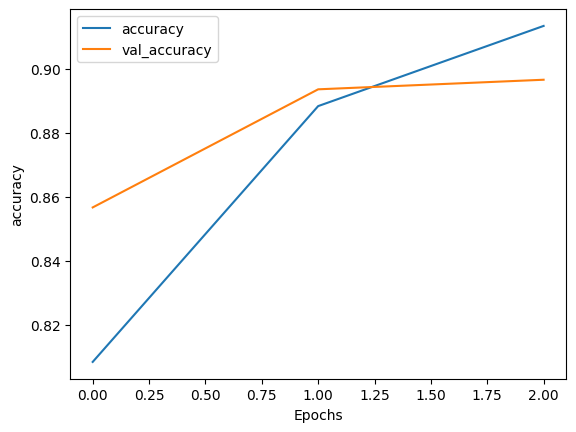

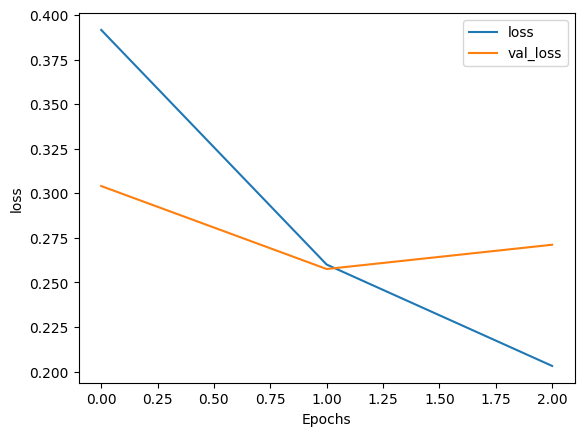

In [16]:
import matplotlib.pyplot as plt

def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.plot(history.history['val_'+string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()

plot_graphs(history, "accuracy")
plot_graphs(history, "loss")

In [17]:
test, val = train_test_split(dev, test_size=dev_size, random_state=42)

In [18]:
dev.shape

(3008, 2)

In [19]:
test.head()

,label,text
8373,0,रिपोर्टर के टोन बहरा सवाल पर america ferrera ...
11380,0,जीवाश्म ईंधन के सहारा देवे वाला 7 मिथक के तोड़त
9656,0,लिंडसी ग्राहम ट्रम्प के चेतावनी दिहले: मुएलर ...
373,1,परिप्रेक्ष्य बदल के पूरा स्थिति बदल जाला।
2507,1,जब हम ना रहब त हमरा के याद करेला


In [20]:
test_encoded = bert_encode(dev.text)

test_dataset = (
    tf.data.Dataset
    .from_tensor_slices(test_encoded)
    .batch(batch_size)
)

predicted_tweets = model.predict(test_dataset, batch_size=batch_size)
predicted_tweets_binary = tf.cast(tf.round(predicted_tweets), tf.int32).numpy().flatten()
print(predicted_tweets_binary)
#my_submission = pd.DataFrame({'id': dev.id, 'label': predicted_tweets_binary})
#my_submission.to_csv('my_submission.csv', index=False)

94/94 [==============================] - 29s 278ms/step
[0 0 0 ... 1 1 0]


In [21]:
from sklearn.metrics import accuracy_score
from sklearn import metrics

In [22]:
print("Bert+LSTM")
print("Accuracy score =", accuracy_score(dev['label'], predicted_tweets_binary))
print(metrics.classification_report(dev['label'], predicted_tweets_binary))


Bert+LSTM
Accuracy score = 0.8966090425531915
              precision    recall  f1-score   support

           0       0.95      0.88      0.91      1811
           1       0.83      0.93      0.88      1197

    accuracy                           0.90      3008
   macro avg       0.89      0.90      0.89      3008
weighted avg       0.90      0.90      0.90      3008

